# Análisis de Regresión - California Housing Prices

Nombre: Elvis Pachacama  
Fecha: 21/05/2026

In [1]:
#Iportamos las librerias de a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler

import zipfile

In [2]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR'] = os.path.expanduser("~/.kaggle")

In [3]:
#Creamos la carpeta dataset
os.makedirs("dataset1", exist_ok=True)

In [4]:
#Descargamos el dataset
!kaggle datasets download -d camnugent/california-housing-prices

Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0




  0%|          | 0.00/400k [00:00<?, ?B/s]
100%|##########| 400k/400k [00:00<00:00, 1.27MB/s]
100%|##########| 400k/400k [00:00<00:00, 1.27MB/s]


In [5]:
#Descompriminos el archivo
with zipfile.ZipFile("california-housing-prices.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset1")

In [6]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset1/housing.csv")
#Leemos las primera filas
print("Primera filas")
display(df.head())

Primera filas


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
#Información general del dataset
print("\nInformación general de dataset:")
df.info()


Información general de dataset:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [8]:
#Exploramos las estadisticas descriptiva
print("\nEstadisticas descriptivas del dataset:")
display(df.describe())


Estadisticas descriptivas del dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 2. Análisis Exploratorio de datos EDA
### 2.1 Distribución de variable numéricas

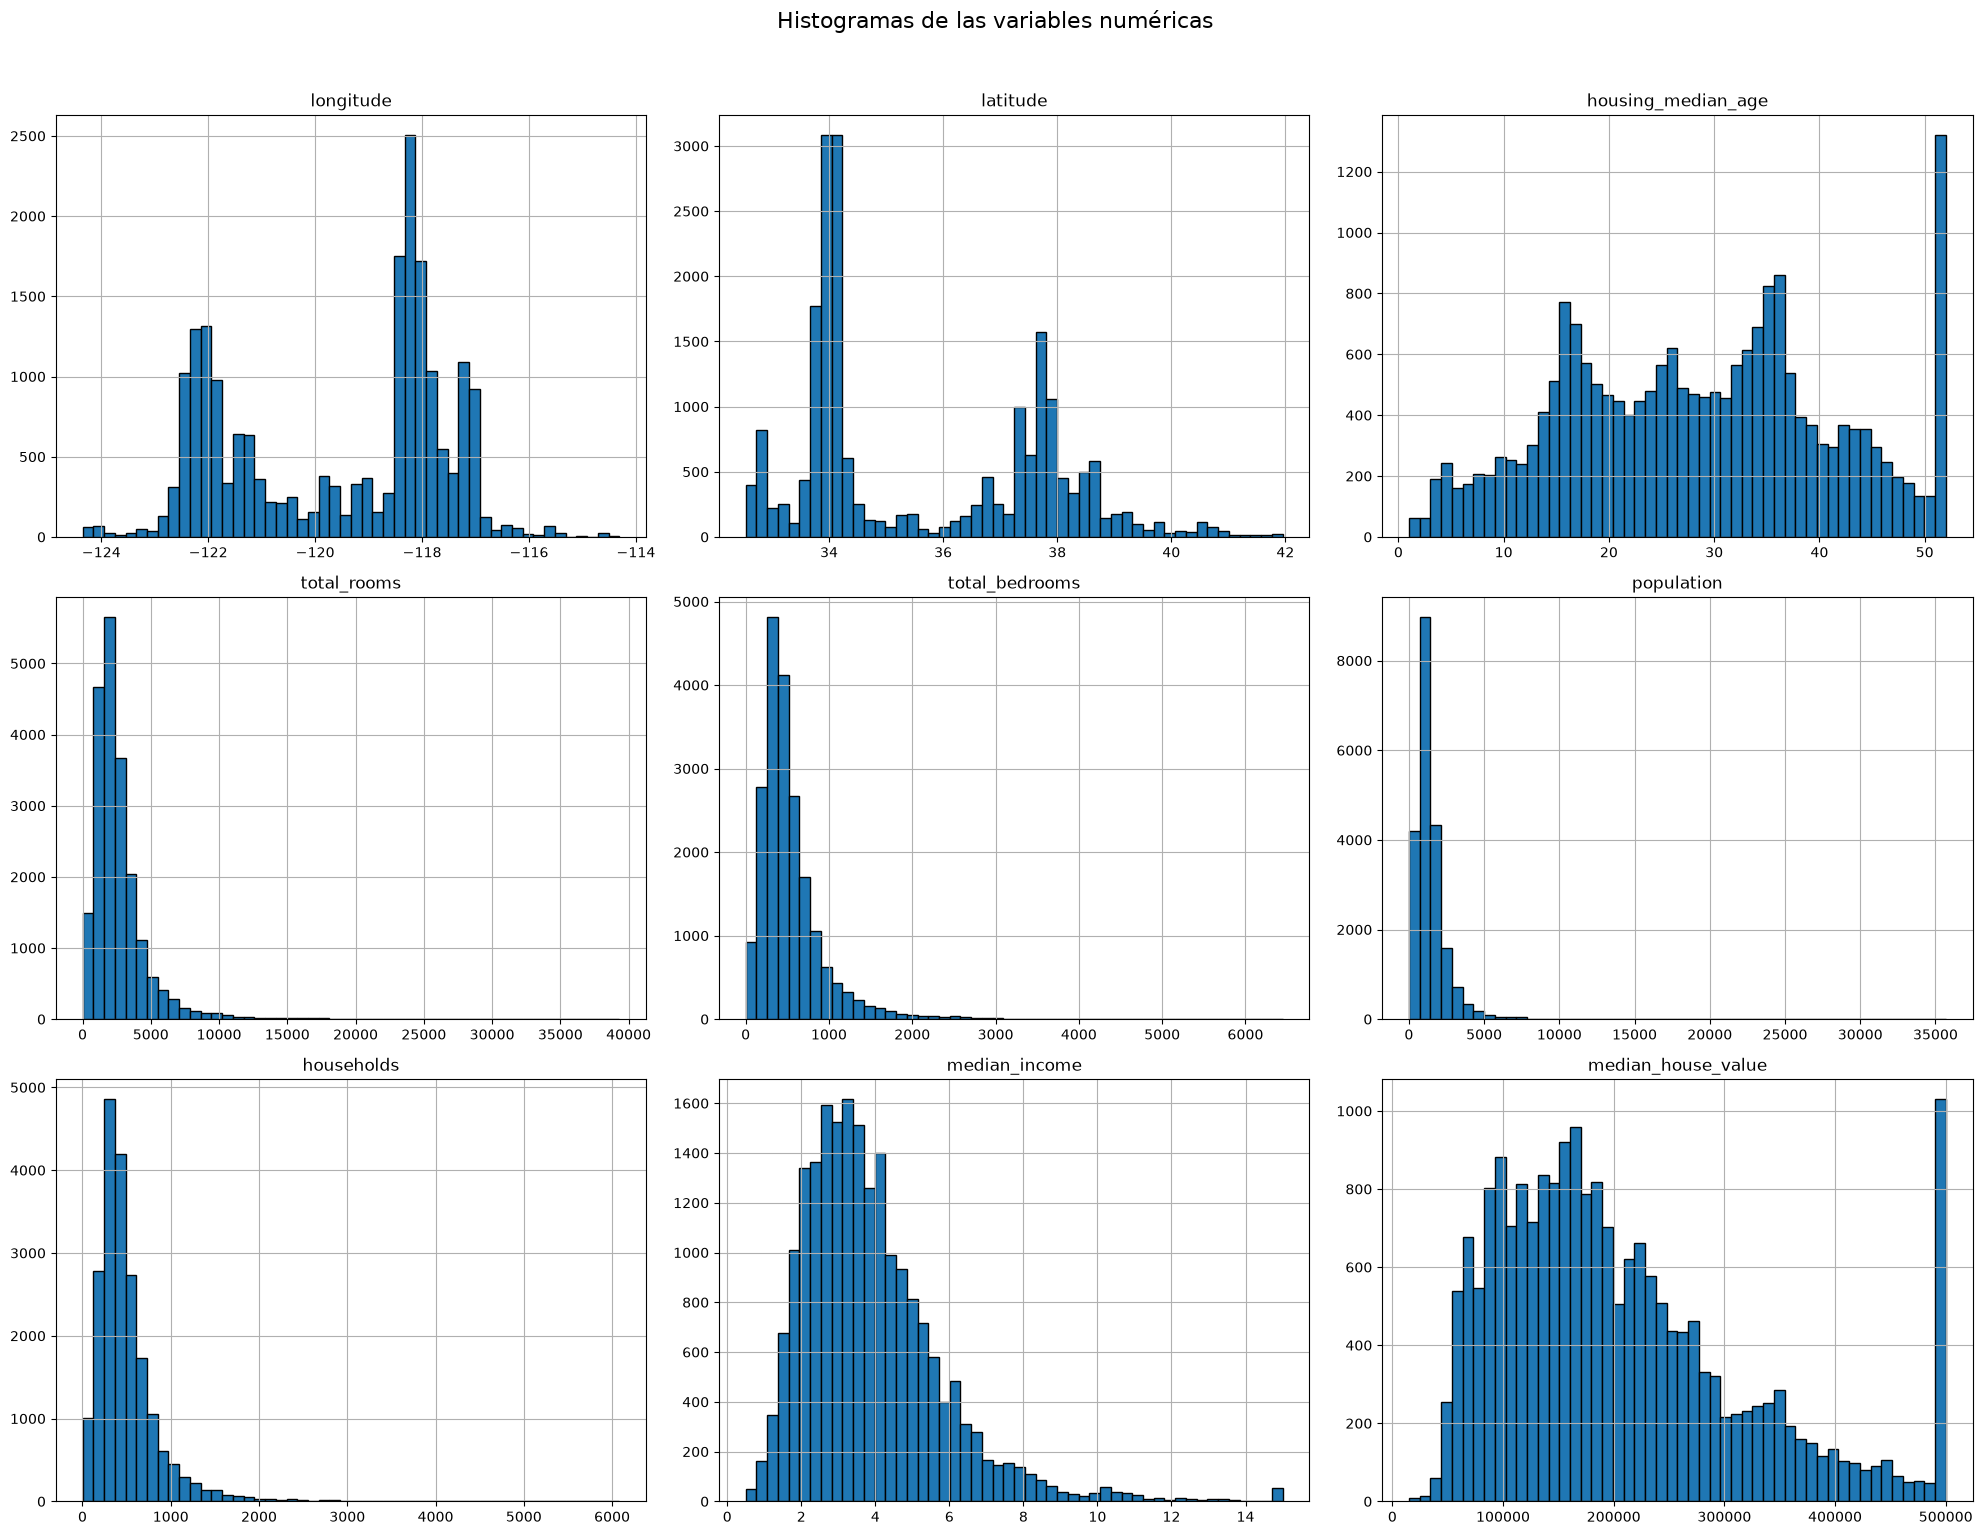

In [9]:
df.hist(figsize=(20,15), bins=50, edgecolor='black')
plt.suptitle("Histogramas de las variables numéricas", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Limpieza y procesamiento de datos

In [10]:
# Imputar los valores faltantes en 'total_bedrooms' con la mediana
mediana_dormitorios = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(mediana_dormitorios)

# Eliminación de topes artificiales ('median_house_value' < 500k y 'housing_median_age' < 52)
df_clean = df[(df['median_house_value'] < 500000) & (df['housing_median_age'] < 52.0)].copy()

# Eliminar valores físicamente imposibles, mas dormitorios que habitaciones
df_clean = df_clean[df_clean['total_bedrooms'] <= df_clean['total_rooms']]

In [11]:
#Visualizo la información del data set
df_clean.info()

<class 'pandas.DataFrame'>
Index: 18551 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           18551 non-null  float64
 1   latitude            18551 non-null  float64
 2   housing_median_age  18551 non-null  float64
 3   total_rooms         18551 non-null  float64
 4   total_bedrooms      18551 non-null  float64
 5   population          18551 non-null  float64
 6   households          18551 non-null  float64
 7   median_income       18551 non-null  float64
 8   median_house_value  18551 non-null  float64
 9   ocean_proximity     18551 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### 2.2 Visualización Espacial

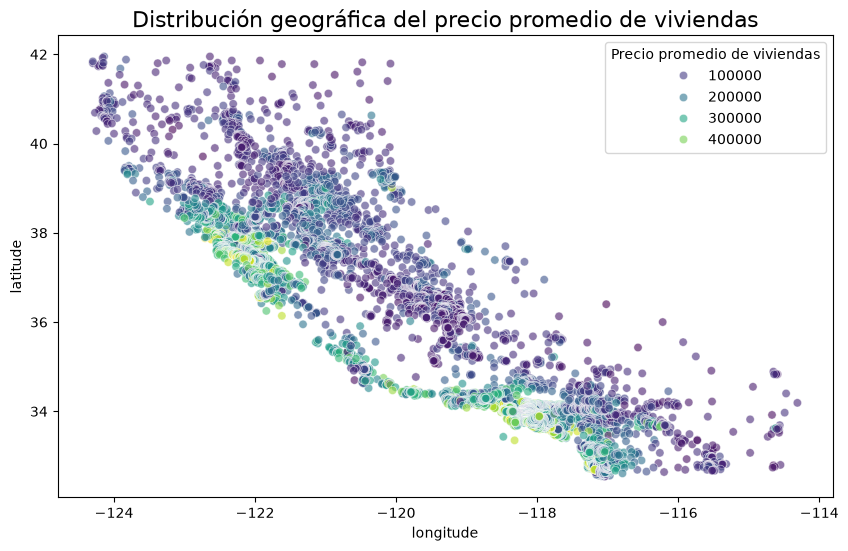

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='median_house_value', palette='viridis', alpha=0.6)
plt.legend(title='Precio promedio de viviendas', loc='upper right')
plt.title('Distribución geográfica del precio promedio de viviendas', fontsize=16)
plt.show()

### 2.3 Análisis de correlación

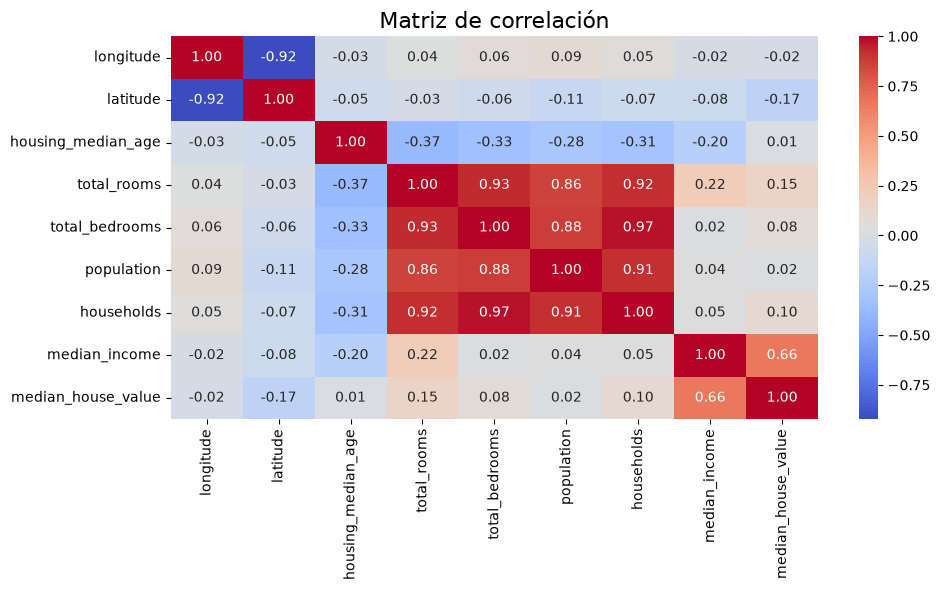

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación', fontsize=16)
plt.tight_layout()
plt.show()

### Ingenieria de caracteristicas

In [14]:
LA, SF = (34.0522, -118.2437), (37.7749, -122.4194)

# Creación de variables geográficas (Proximidad a centros económicos) función de distancia eucliniana
df_clean['dist_to_LA'] = np.sqrt((df_clean['latitude'] - LA[0])**2 + (df_clean['longitude'] - LA[1])**2)
df_clean['dist_to_SF'] = np.sqrt((df_clean['latitude'] - SF[0])**2 + (df_clean['longitude'] - SF[1])**2)

# Ratios
# Vamos a calcular el promedio de dormitorios por habitaciones
df_clean['bedrooms_per_room'] = df_clean['total_bedrooms'] / df_clean['total_rooms']

#Cuantas personas viven por cada casa
df_clean['pop_per_household'] = df_clean['population'] / df_clean['households']

# Encoding de variables categoricas
df_clean = pd.get_dummies(df_clean, columns=['ocean_proximity'], drop_first=True)

### Analisis de Correlación de las nuevas variables

In [15]:
corr_matriz = df_clean.corr()
print("\nCorrelación respecto al precio promedio de viviendas:")
display(corr_matriz['median_house_value'].sort_values(ascending=False))


Correlación respecto al precio promedio de viviendas:


median_house_value            1.000000
median_income                 0.664341
total_rooms                   0.153769
ocean_proximity_NEAR OCEAN    0.147346
ocean_proximity_NEAR BAY      0.111688
households                    0.100436
total_bedrooms                0.079249
population                    0.022399
ocean_proximity_ISLAND        0.019534
housing_median_age            0.014207
dist_to_SF                   -0.015476
pop_per_household            -0.020200
longitude                    -0.022912
dist_to_LA                   -0.143450
latitude                     -0.171567
bedrooms_per_room            -0.227051
ocean_proximity_INLAND       -0.501263
Name: median_house_value, dtype: float64

### Preparación de Datos para el Modelado

In [16]:
# Definir las variables predictoras y la variable objetivo
X = df_clean.drop('median_house_value', axis=1)
y = df_clean['median_house_value']

# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
#print(X)
#print(y)

### Modelado y Entrenamiento

In [18]:
# Instanciar y entrenar el modelo de regresión lineal
linear_model = LinearRegression()
ridge_model = Ridge(alpha=10.0, random_state=42) # alpha es la fuerza de regularización
lasso_model = Lasso(alpha=50, random_state=42, max_iter=10000)

#Entrenamos los modelos de aprendizaje
linear_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",50
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


### Regresión lineal Standard

In [19]:
# Predicciones entrenamiento
y_train_pred_linear = linear_model.predict(X_train_scaled)
# Predicciones prueba
y_test_pred_linear = linear_model.predict(X_test_scaled)

# Cálculo de RMSE. Formula: RMSE: sqrt(mean((y_true - y_pred)^2))
rmse_train_linear = np.sqrt(np.mean((y_train - y_train_pred_linear) ** 2))
rmse_test_linear = np.sqrt(np.mean((y_test - y_test_pred_linear) ** 2))

#Calculo de MAE
mae_train_linear = np.mean(np.abs(y_train - y_train_pred_linear))
mae_test_linear = np.mean(np.abs(y_test - y_test_pred_linear))

#Mostramos los resultados
print(f"Linear - RMSE Train: {rmse_train_linear:.2f}")
print(f"Linear - RMSE Test: {rmse_test_linear:.2f}")
print(f"Linear - MAE Train: {mae_train_linear:.2f}")
print(f"Linear - MAE Test: {mae_test_linear:.2f}")

#Importancia de variables
coef_linear = pd.DataFrame({'Característica': X.columns, 'Importancia': linear_model.coef_.round(3)})
coef_linear = coef_linear.sort_values(by='Importancia', key=abs, ascending=False)
display(coef_linear.head(10))

Linear - RMSE Train: 57330.01
Linear - RMSE Test: 57261.37
Linear - MAE Train: 41955.67
Linear - MAE Test: 42267.33


,Característica,Importancia
7,median_income,61997.456
5,population,-38464.037
6,households,29993.851
0,longitude,-26311.551
8,dist_to_LA,-23266.464
12,ocean_proximity_INLAND,-21393.725
1,latitude,-17693.367
9,dist_to_SF,-15731.574
10,bedrooms_per_room,11404.580
3,total_rooms,7104.186


### Modelo Ridge

In [20]:
# Predicciones
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Cálculo de RMSE. Formula: RMSE: sqrt(mean((y_true - y_pred)^2))
rmse_train_ridge = np.sqrt(np.mean((y_train - y_train_pred_ridge) ** 2))
rmse_test_ridge = np.sqrt(np.mean((y_test - y_test_pred_ridge) ** 2))

print(f"Ridge - RMSE Train: {rmse_train_ridge:.2f}")
print(f"Ridge - RMSE Test: {rmse_test_ridge:.2f}")

mae_train_ridge = np.mean(np.abs(y_train - y_train_pred_ridge))
mae_test_ridge = np.mean(np.abs(y_test - y_test_pred_ridge))
print(f"MAE Train: {mae_train_ridge:.2f}")
print(f"MAE Test: {mae_test_ridge:.2f}")

# Ver qué variables tienen coeficientes más grandes en el modelo Ridge
coeficientes = pd.DataFrame({'Característica': X.columns, 'Importancia': ridge_model.coef_.round(3)}).sort_values(by='Importancia', key=abs, ascending=False)
print("\nImportancia de las características según el modelo Ridge:")
display(coeficientes.head(10))

Ridge - RMSE Train: 57330.29
Ridge - RMSE Test: 57255.13
MAE Train: 41958.59
MAE Test: 42264.60

Importancia de las características según el modelo Ridge:


,Característica,Importancia
7,median_income,61934.472
5,population,-38153.471
6,households,29423.475
0,longitude,-25702.655
8,dist_to_LA,-23197.983
12,ocean_proximity_INLAND,-21555.084
1,latitude,-17313.545
9,dist_to_SF,-15949.976
10,bedrooms_per_room,11325.072
3,total_rooms,6999.325


### Modelo Lasso (Regularización L1)

In [21]:
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(np.mean((y_train - y_train_pred_lasso) ** 2))
rmse_test_lasso = np.sqrt(np.mean((y_test - y_test_pred_lasso) ** 2))

print(f"Lasso - RMSE Train: {rmse_train_lasso:.2f}")
print(f"Lasso - RMSE Test: {rmse_test_lasso:.2f}")

mae_train_lasso = np.mean(np.abs(y_train - y_train_pred_lasso))
mae_test_lasso = np.mean(np.abs(y_test - y_test_pred_lasso))
print(f"MAE Train: {mae_train_lasso:.2f}")
print(f"MAE Test: {mae_test_lasso:.2f}")

# Ver qué variables tienen coeficientes más grandes en el modelo Lasso
coeficientes_lasso = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': lasso_model.coef_.round(3)
}).sort_values(by='Importancia', key=abs, ascending=False)
print("\nImportancia de las características según el modelo Lasso:")
display(coeficientes_lasso.head())

# Ver si lasso ha eliminado alguna variable (coeficiente exactamente 0)
variables_eliminadas = coeficientes_lasso[coeficientes_lasso['Importancia'] == 0]['Característica'].tolist()
print(f"\nVariables eliminadas por Lasso (coeficiente 0): {variables_eliminadas}")

Lasso - RMSE Train: 57331.80
Lasso - RMSE Test: 57253.64
MAE Train: 41953.47
MAE Test: 42260.12

Importancia de las características según el modelo Lasso:


,Característica,Importancia
7,median_income,61978.503
5,population,-37742.180
6,households,29465.904
0,longitude,-24923.557
8,dist_to_LA,-23182.754



Variables eliminadas por Lasso (coeficiente 0): []


### Graficas Valores Reales vs Predichos

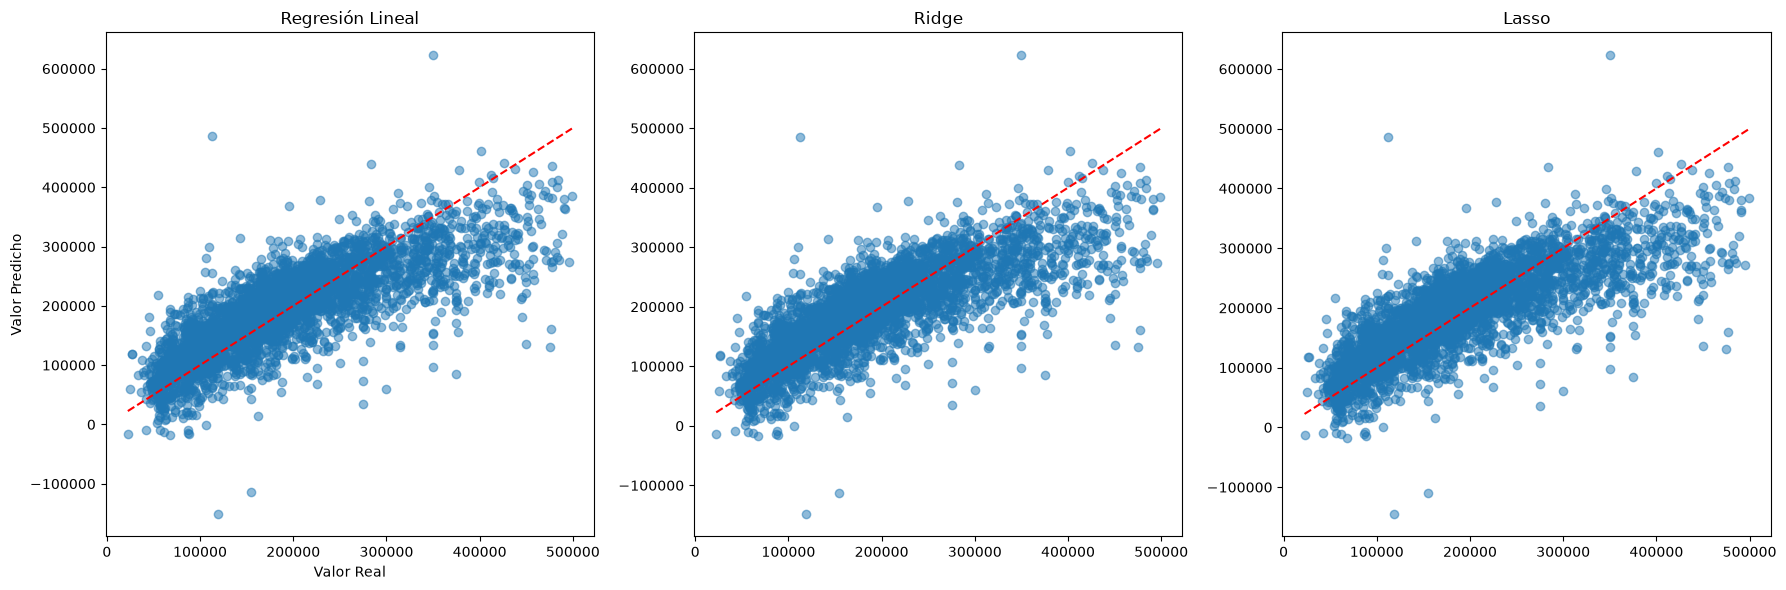

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))

#Linear
ax[0].scatter(y_test, y_test_pred_linear, alpha=0.5)
ax[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[0].set_title("Regresión Lineal")
ax[0].set_xlabel("Valor Real")
ax[0].set_ylabel("Valor Predicho")

#Ridge
ax[1].scatter(y_test, y_test_pred_ridge, alpha=0.5)
ax[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[1].set_title("Ridge")

# Lasso
ax[2].scatter(y_test, y_test_pred_lasso, alpha=0.5)
ax[2].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[2].set_title("Lasso")

plt.tight_layout()
plt.show()

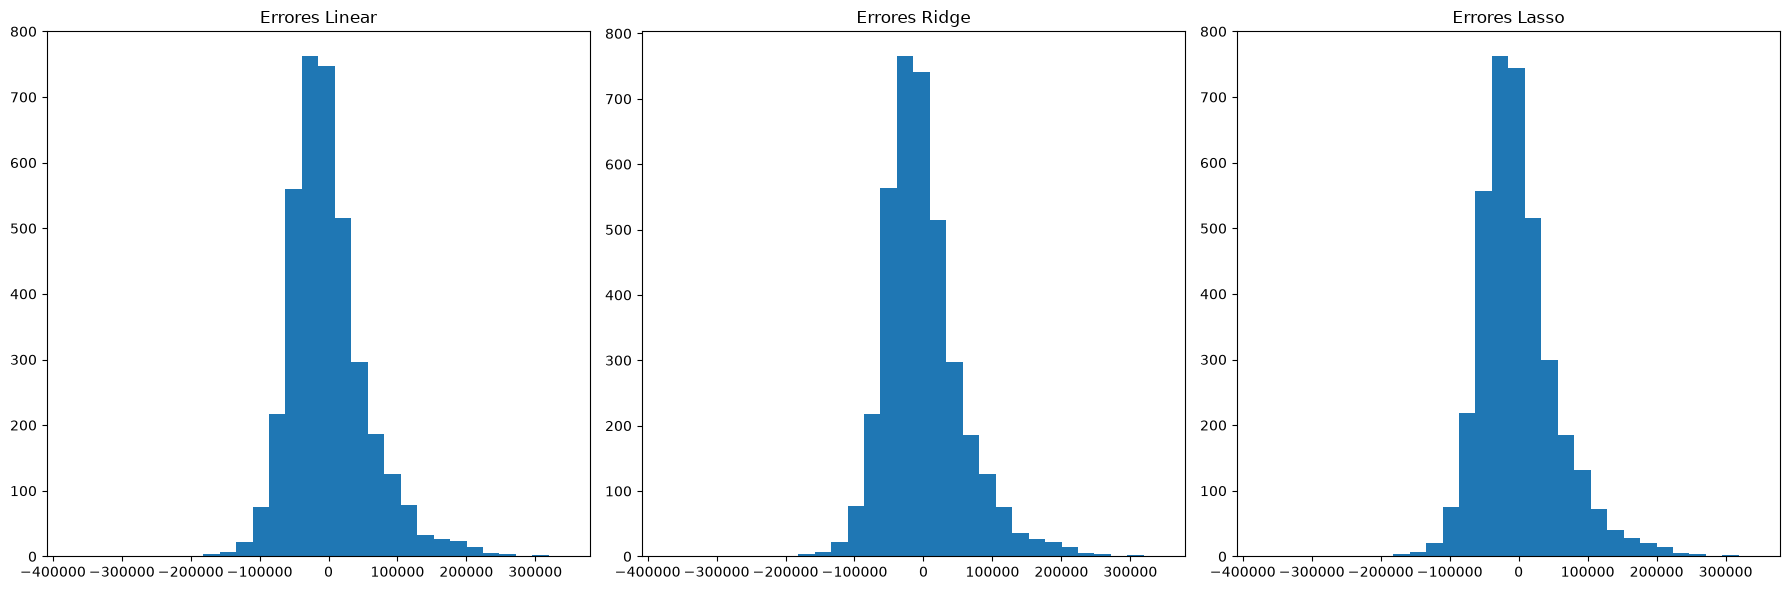

In [23]:
#Histogrma de error
fig, ax = plt.subplots(1,3, figsize=(18,6))

# Linear
ax[0].hist(
    y_test - y_test_pred_linear,
    bins=30
)
ax[0].set_title("Errores Linear")

# Ridge
ax[1].hist(
    y_test - y_test_pred_ridge,
    bins=30
)
ax[1].set_title("Errores Ridge")

# Lasso
ax[2].hist(
    y_test - y_test_pred_lasso,
    bins=30
)
ax[2].set_title("Errores Lasso")

plt.tight_layout()
plt.show()

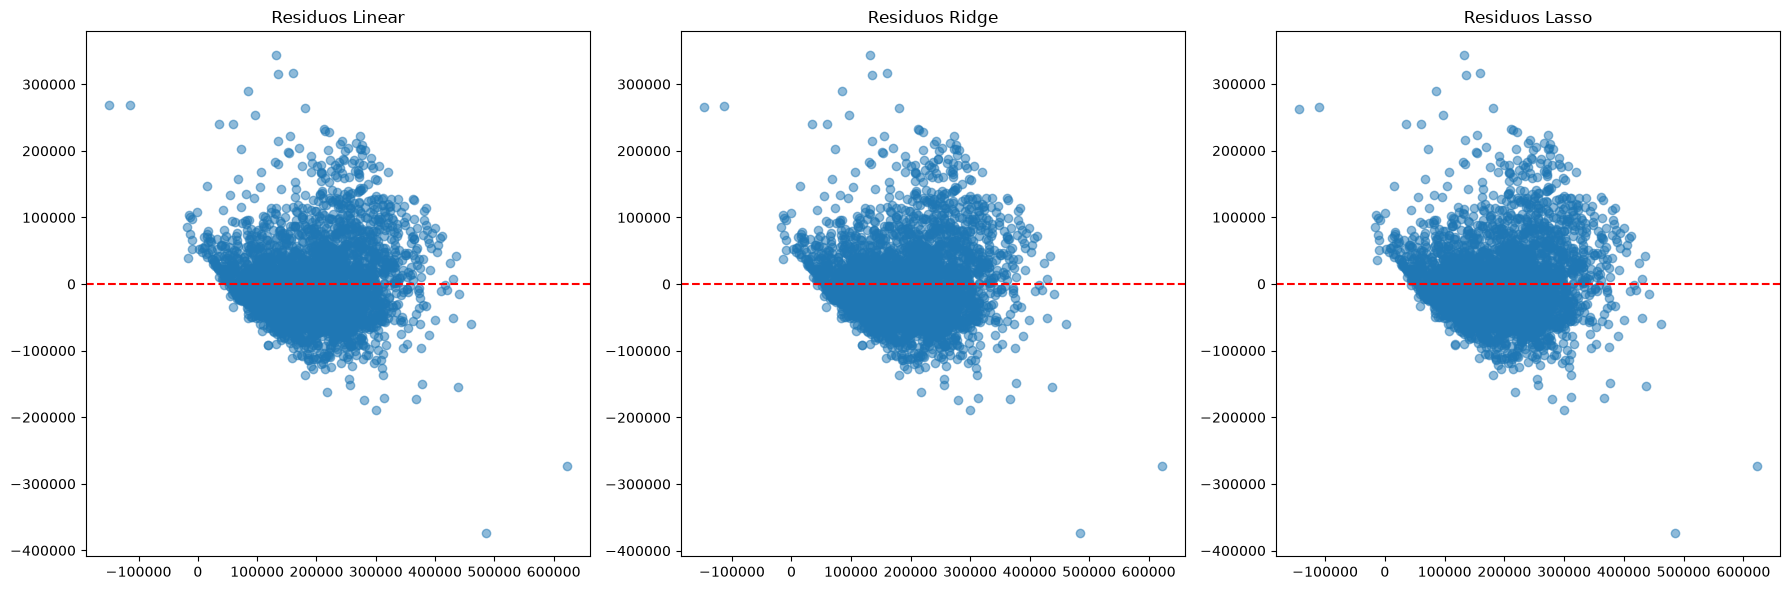

In [24]:
fig, ax = plt.subplots(1,3, figsize=(18,6))

# Linear
res_linear = y_test - y_test_pred_linear
ax[0].scatter(
    y_test_pred_linear,
    res_linear,
    alpha=0.5
)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title("Residuos Linear")

# Ridge
res_ridge = y_test - y_test_pred_ridge
ax[1].scatter(
    y_test_pred_ridge,
    res_ridge,
    alpha=0.5
)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title("Residuos Ridge")

# Lasso
res_lasso = y_test - y_test_pred_lasso
ax[2].scatter(
    y_test_pred_lasso,
    res_lasso,
    alpha=0.5
)
ax[2].axhline(0, color='red', linestyle='--')
ax[2].set_title("Residuos Lasso")

plt.tight_layout()
plt.show()

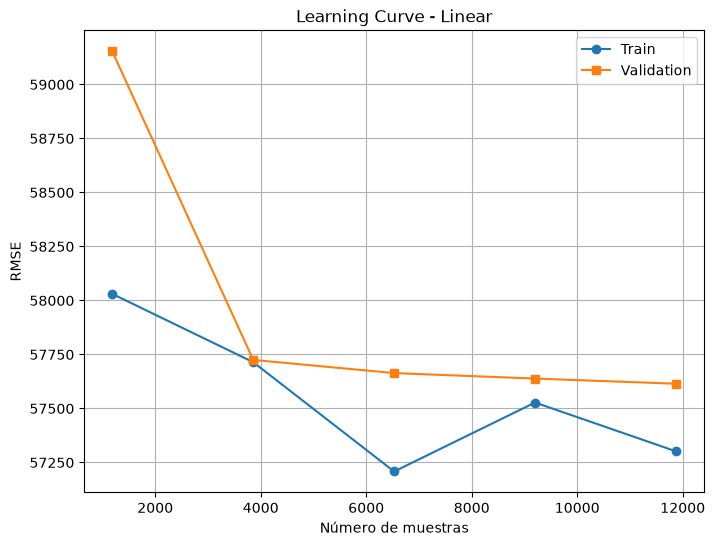

In [25]:
#Curva de aprendizaje regresión standard
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    linear_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Linear")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

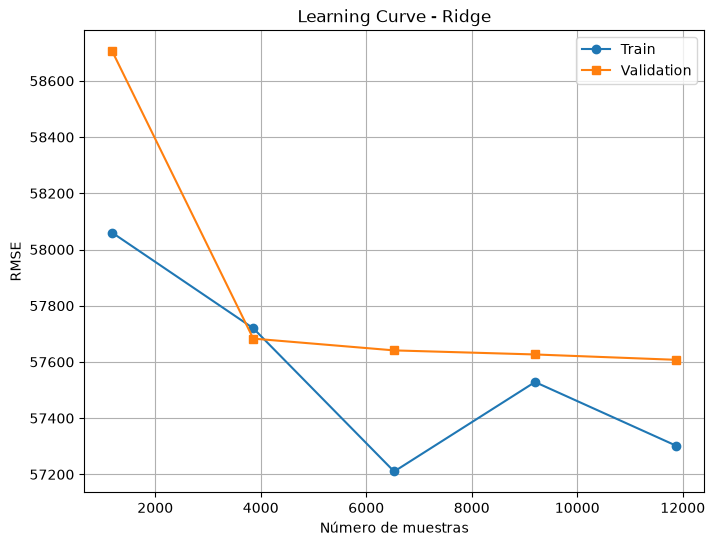

In [26]:
#Curva de aprendizaje regresión ridge
train_sizes, train_scores, test_scores = learning_curve(
    ridge_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Ridge")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

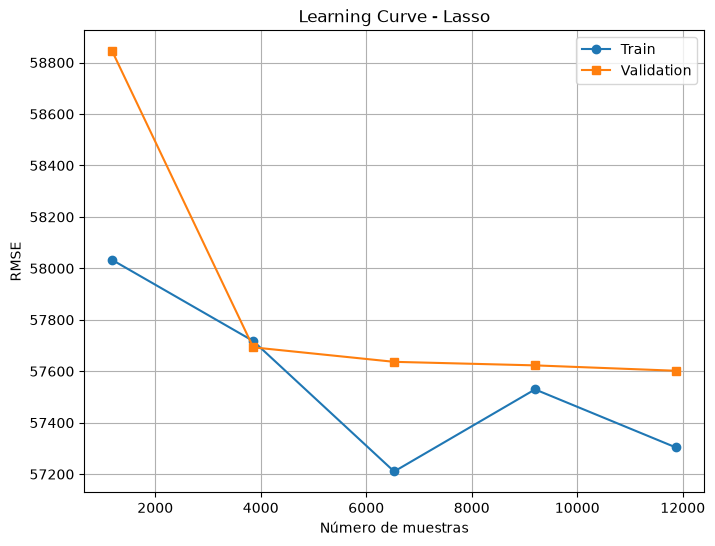

In [27]:
#Curva de aprendizaje regresión lasso
train_sizes, train_scores, test_scores = learning_curve(
    lasso_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Lasso")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

### Conclusión

* **Diagnóstico de Sobreajuste (Overfitting):** El Error Cuadrático Medio (RMSE) en los conjuntos de entrenamiento y prueba es sumamente similar para ambos modelos. Esto indica que la regularización aplicada es efectiva y que los modelos generalizan correctamente sin memorizar el ruido de entrenamiento.
* **Comportamiento del Modelo Lasso (L1):** A pesar del uso de regularización L1 (con alpha=50), el modelo Lasso no ha reducido a cero ningún coeficiente. Esto sugiere que, a este nivel de penalización, todas las características de entrada conservan relevancia predictiva y no hay redundancia crítica.
* **Comparativa de Modelos:** El modelo Ridge (L2) presenta un rendimiento marginalmente superior en el conjunto de prueba, lo que indica que una penalización suave distribuida sobre todas las variables (L2) es más adecuada para este conjunto de datos que la selección estricta de variables (L1).

In [28]:
### Comparación de los modelos

In [29]:
comparacion = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso'],
    'RMSE Train': [
        rmse_train_linear,
        rmse_train_ridge,
        rmse_train_lasso
    ],
    'RMSE Test': [
        rmse_test_linear,
        rmse_test_ridge,
        rmse_test_lasso
    ],
    'MAE Train': [
        mae_train_linear,
        mae_train_ridge,
        mae_train_lasso
    ],
    'MAE Test': [
        mae_test_linear,
        mae_test_ridge,
        mae_test_lasso
    ]
})
comparacion

,Modelo,RMSE Train,RMSE Test,MAE Train,MAE Test
0,Linear,57330.006736,57261.373128,41955.672722,42267.328597
1,Ridge,57330.293705,57255.128087,41958.589108,42264.599484
2,Lasso,57331.799208,57253.640824,41953.469481,42260.119648


In [31]:
#Deber para terminar el pipeline guardar y cargar el modelo lasso e ingresar nuevos valores por teclado y predecir el precio de una vivienda.

In [30]:
import joblib

# Guardar el modelo Lasso y el scaler
joblib.dump(lasso_model, 'modelo_lasso.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Modelo y scaler guardados correctamente.")

Modelo y scaler guardados correctamente.


In [32]:
# Cargar el modelo y el scaler
lasso_cargado = joblib.load('modelo_lasso.pkl')
scaler_cargado = joblib.load('scaler.pkl')
print("Modelo y scaler cargados correctamente.")

Modelo y scaler cargados correctamente.


In [33]:
import numpy as np
import pandas as pd

def predecir_precio():
    """
    Solicita al usuario los datos de una vivienda y devuelve el precio estimado.
    """
    print("\n--- Ingrese los datos de la vivienda ---")
    
    # Solicitar valores de las características originales
    longitude = float(input("Longitud (ej. -122.23): "))
    latitude = float(input("Latitud (ej. 37.88): "))
    housing_median_age = float(input("Edad mediana de la vivienda (años): "))
    total_rooms = float(input("Número total de habitaciones: "))
    total_bedrooms = float(input("Número total de dormitorios: "))
    population = float(input("Población: "))
    households = float(input("Número de hogares: "))
    median_income = float(input("Ingreso mediano (en decenas de miles de dólares): "))
    ocean_proximity = input("Proximidad al océano (INLAND, NEAR BAY, NEAR OCEAN, ISLAND, <1H OCEAN): ").strip()
    
    # Crear un DataFrame con una sola fila
    datos = pd.DataFrame({
        'longitude': [longitude],
        'latitude': [latitude],
        'housing_median_age': [housing_median_age],
        'total_rooms': [total_rooms],
        'total_bedrooms': [total_bedrooms],
        'population': [population],
        'households': [households],
        'median_income': [median_income],
        'ocean_proximity': [ocean_proximity]
    })
    
    # Aplicar las mismas transformaciones que en el entrenamiento
    # Coordenadas de Los Ángeles y San Francisco (usadas en el notebook)
    LA = (34.0522, -118.2437)
    SF = (37.7749, -122.4194)
    
    datos['dist_to_LA'] = np.sqrt((datos['latitude'] - LA[0])**2 + (datos['longitude'] - LA[1])**2)
    datos['dist_to_SF'] = np.sqrt((datos['latitude'] - SF[0])**2 + (datos['longitude'] - SF[1])**2)
    datos['bedrooms_per_room'] = datos['total_bedrooms'] / datos['total_rooms']
    datos['pop_per_household'] = datos['population'] / datos['households']
    
    # Codificar la variable categórica ocean_proximity (drop_first=True)
    # Para asegurar que las columnas coincidan con las del entrenamiento,
    # usamos pd.get_dummies y luego reindexamos con las columnas originales.
    datos_dummies = pd.get_dummies(datos, columns=['ocean_proximity'], drop_first=True)
    
    # Obtener las columnas que se usaron en el entrenamiento (excluyendo la variable objetivo)
    columnas_entrenamiento = X.columns.tolist()  # X es el DataFrame de características del entrenamiento
    
    # Asegurar que todas las columnas estén presentes; las que faltan se rellenan con 0
    for col in columnas_entrenamiento:
        if col not in datos_dummies.columns:
            datos_dummies[col] = 0
    
    # Reordenar las columnas según el orden del entrenamiento
    datos_dummies = datos_dummies[columnas_entrenamiento]
    
    # Escalar las características
    datos_scaled = scaler_cargado.transform(datos_dummies)
    
    # Realizar la predicción
    precio_predicho = lasso_cargado.predict(datos_scaled)[0]
    
    print(f"\nPrecio estimado de la vivienda: ${precio_predicho:,.2f}")
    return precio_predicho

In [34]:
# Llamar a la función para predecir
predecir_precio()


--- Ingrese los datos de la vivienda ---


Longitud (ej. -122.23):  -102.56
Latitud (ej. 37.88):  37.22
Edad mediana de la vivienda (años):  25
Número total de habitaciones:  7
Número total de dormitorios:  2
Población:  322
Número de hogares:  126
Ingreso mediano (en decenas de miles de dólares):  8.3252
Proximidad al océano (INLAND, NEAR BAY, NEAR OCEAN, ISLAND, <1H OCEAN):  NEAR BAY



Precio estimado de la vivienda: $-63,538.70


np.float64(-63538.69544018168)